In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('Gaming_Academic_Performance.csv')

In [2]:
import os
os.makedirs('figures', exist_ok=True)

In [3]:
dataset.dropna()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,24,Male,6.33,5.09,4.83,63.74,FPS,4.11,9.96,231.33,11.14,Low,35.110000
7996,7997,22,Female,5.77,6.09,6.23,84.37,FPS,3.42,11.19,254.13,10.66,Low,60.800000
7997,7998,20,Male,2.87,8.51,8.62,67.30,FPS,2.36,6.40,305.00,6.42,Medium,90.280000
7998,7999,22,Female,0.98,2.99,7.29,61.13,FPS,2.02,4.57,325.36,2.14,Medium,56.330000


In [4]:
from sklearn.model_selection import train_test_split

bins= [-float("inf"), 59, 69, 79, 89, float("inf")]
labels = ['F', 'D', 'C', 'B', 'A']

dataset["letter_grade"] = pd.cut(dataset["grades"], bins=bins, labels=labels)


In [5]:
train_set, test_set = train_test_split(dataset, test_size=.2, 
                                       stratify=dataset["letter_grade"], 
                                       random_state=42)

Objective: Predict Grades with features.

In [6]:
y_train = train_set[["grades"]]
x_train = train_set.drop(columns=["grades", "letter_grade"])

y_test = test_set[["grades"]]
x_test = test_set.drop(columns=["grades", "letter_grade"])

In [7]:
x_train.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level
3174,3175,18,Male,0.37,3.99,7.26,82.18,RPG,3.15,5.94,311.57,4.27,Medium
830,831,23,Female,4.71,4.13,5.40,94.81,RPG,4.85,9.68,250.81,13.62,Medium
4030,4031,21,Male,5.46,5.09,4.28,79.45,Casual,3.40,10.29,257.58,17.03,Low
6386,6387,20,Male,1.44,5.64,6.30,83.00,FPS,2.26,4.58,277.97,1.95,Medium
4288,4289,17,Male,5.79,9.17,4.21,78.66,RPG,0.53,7.48,246.99,13.74,High


In [8]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 6400 entries, 3174 to 2038
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        6400 non-null   int64  
 1   age               6400 non-null   int64  
 2   gender            6400 non-null   str    
 3   gaming_hours      6400 non-null   float64
 4   study_hours       6400 non-null   float64
 5   sleep_hours       6400 non-null   float64
 6   attendance        6400 non-null   float64
 7   gaming_genre      6400 non-null   str    
 8   social_activity   6400 non-null   float64
 9   device_usage      6400 non-null   float64
 10  reaction_time_ms  6400 non-null   float64
 11  addiction_score   6400 non-null   float64
 12  stress_level      6400 non-null   str    
dtypes: float64(8), int64(2), str(3)
memory usage: 700.0 KB


In [9]:
x_train.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score
count,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000,6400.000000
mean,3990.127344,19.991719,4.103270,5.477133,6.483722,79.822450,2.507405,7.601766,270.863412,9.946709
std,2312.594629,2.583640,2.310531,2.578738,1.442074,11.581862,1.440893,2.719966,29.486837,5.041467
min,1.000000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000
25%,1975.750000,18.000000,2.130000,3.277500,5.230000,69.737500,1.290000,5.590000,246.847500,5.980000
50%,4003.500000,20.000000,4.175000,5.470000,6.500000,79.600000,2.490000,7.630000,270.400000,10.070000
75%,5995.500000,22.000000,6.080000,7.670000,7.710000,90.012500,3.762500,9.620000,294.522500,13.832500
max,8000.000000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000


In [10]:
x_train.drop(columns=["student_id"], inplace=True)

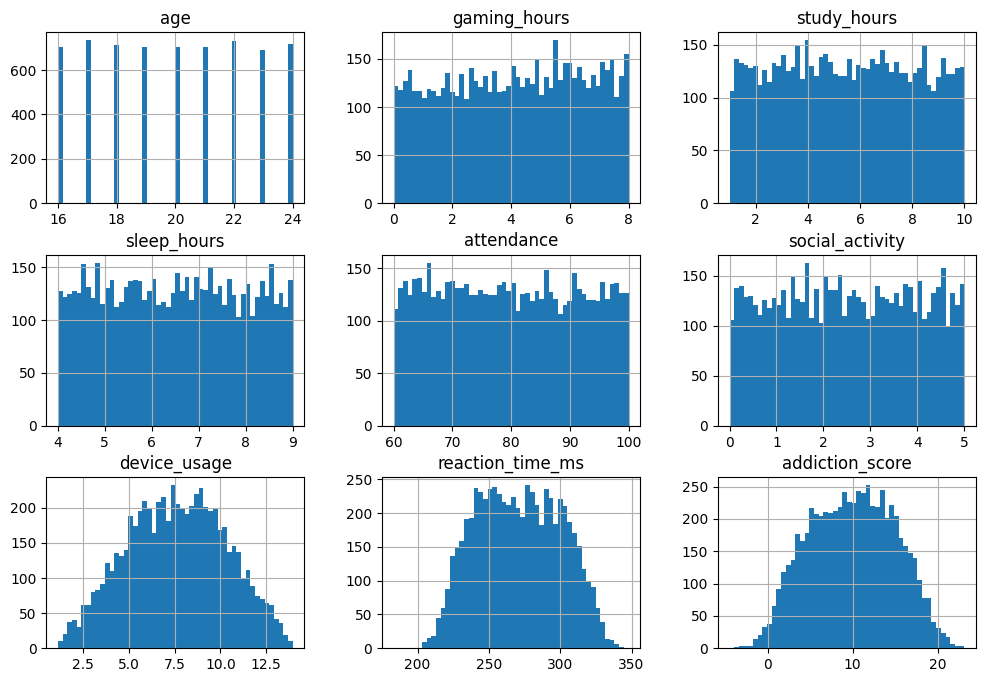

In [11]:
x_train.hist(bins=50, figsize=(12, 8))
plt.savefig('figures/gaming_feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

Mostly Uniform while device_usage, reaction_time, and addiction_score are normally distributed.

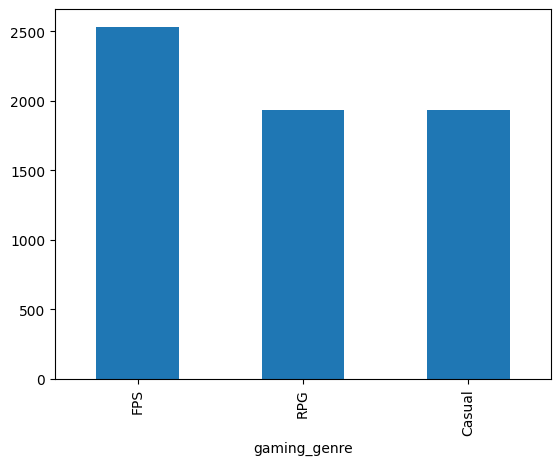

In [12]:
train_set["gaming_genre"].value_counts().plot(kind="bar")
plt.savefig('figures/gaming_genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

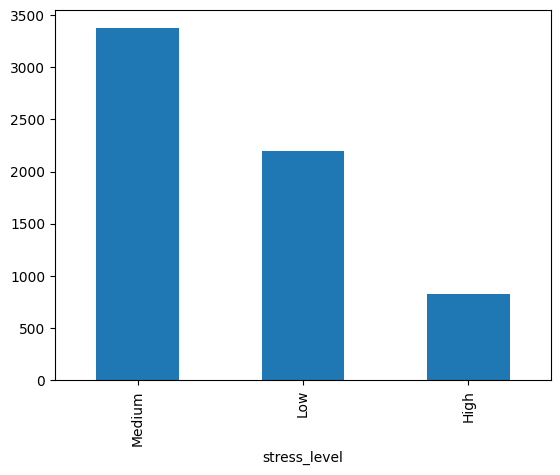

In [13]:
train_set["stress_level"].value_counts().plot(kind="bar")
plt.savefig('figures/stress_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

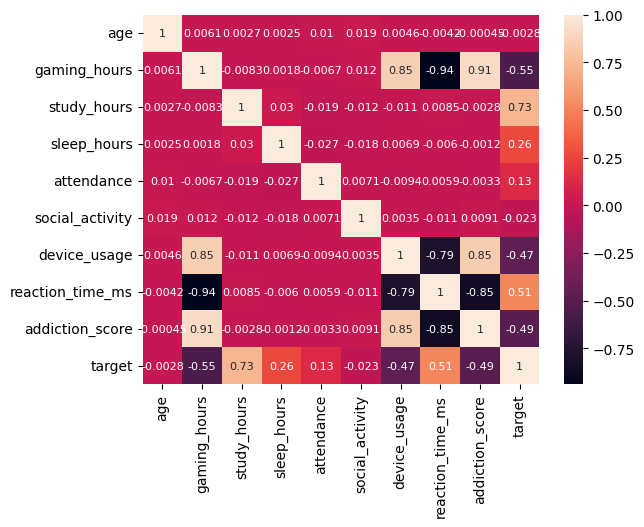

In [14]:
numeric_cols = x_train.select_dtypes(include="number").columns

df = x_train[numeric_cols].copy()
df["target"] = y_train

sns.heatmap(df.corr(), annot=True, annot_kws={"size": 8})
plt.savefig('figures/gaming_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Study Hours is highly correlated. Reaction_time is interestingly fairly positively correlated. addiction_score is negatively correlated, as is device usage and gaming hours.

Age and social activity don't really seem to matter all that much. 
Reaction time has strong negative correlations with addiction_score, device usage, and gaming_hours
As these increase reaction_time decreases -> as reaction_time decreases, grade decreases


In [15]:
import numpy as np

np.ravel(y_train)

array([ 76.6 ,  53.75,  54.79, ...,  99.  , 100.  ,  66.23], shape=(6400,))

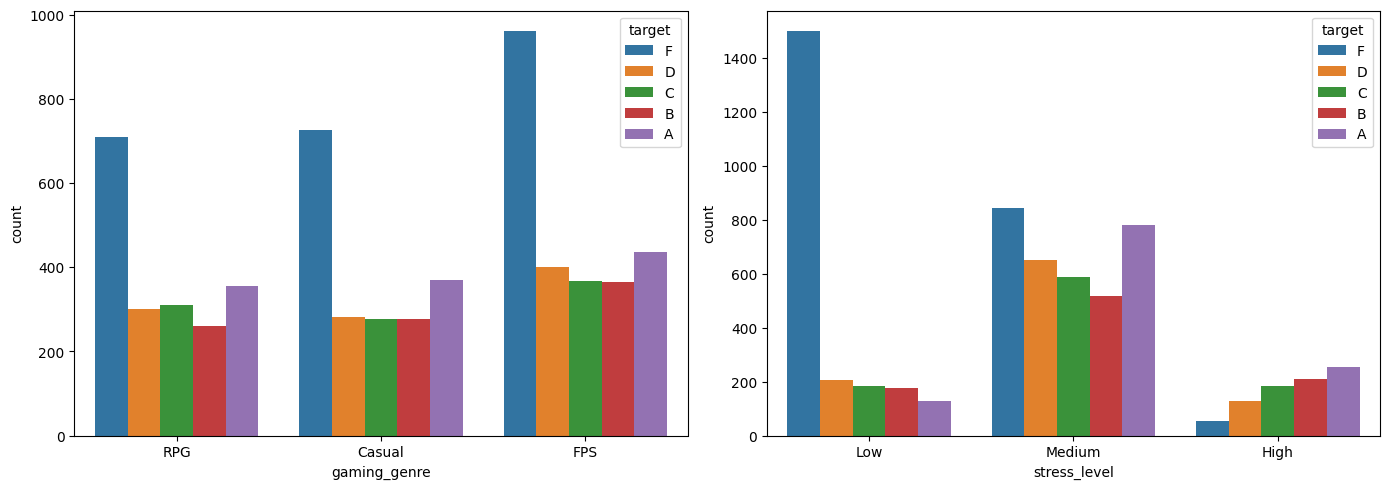

In [16]:
df = x_train.copy()
df["target"] = pd.cut(
    np.ravel(y_train),
    bins=[-float('inf'), 59, 69, 79, 89, float('inf')],
    labels=["F", "D", "C", "B", "A"],
    include_lowest=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="gaming_genre", hue="target", ax=axes[0])
sns.countplot(data=df, x="stress_level", hue="target", ax=axes[1],
              order=["Low", "Medium", "High"])

plt.tight_layout()
plt.savefig('figures/gaming_genre_stress_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

Gaming genre doesn't really seem to matter but stress_level seems to be a massive indicator.. in the opposite way that I thought it would though.

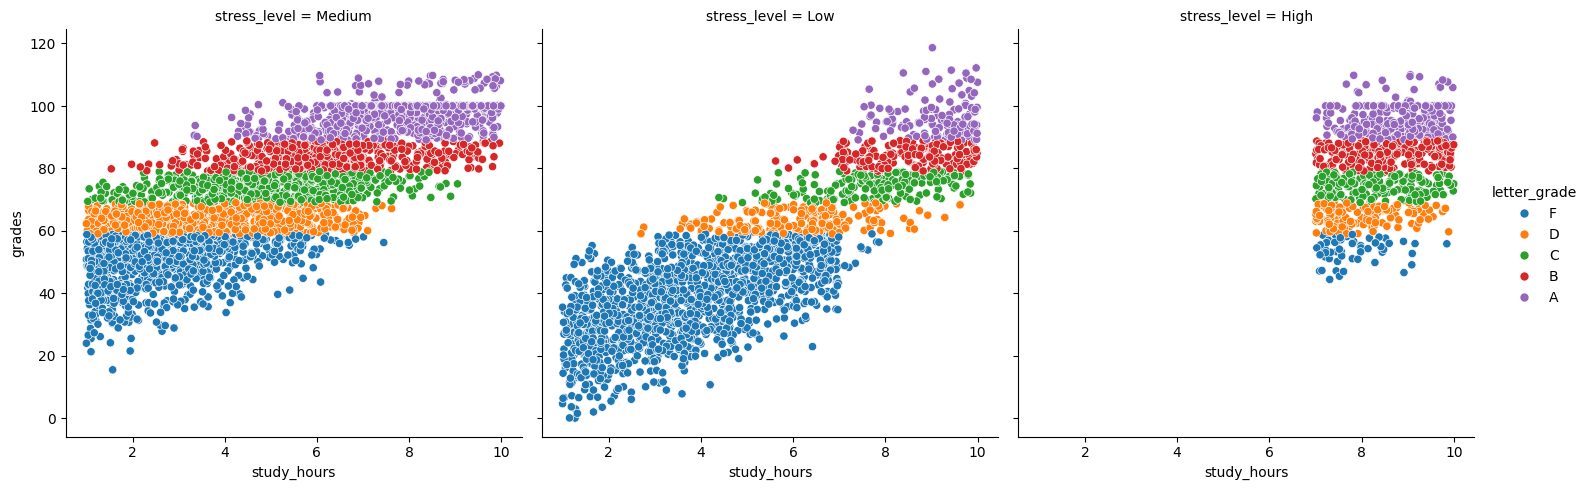

In [17]:
g = sns.relplot(data=train_set, x="study_hours", y="grades", hue="letter_grade", col="stress_level")
g.savefig('figures/gaming_study_hours_vs_grades.png', dpi=150, bbox_inches='tight')

Notes from this: Stress level high is highly correlated with study hours. Stress level in general once again seems to be a massive predictor.

In [18]:
numeric_cols = train_set.select_dtypes(include="number").columns 
numeric_cols

Index(['student_id', 'age', 'gaming_hours', 'study_hours', 'sleep_hours',
       'attendance', 'social_activity', 'device_usage', 'reaction_time_ms',
       'addiction_score', 'grades'],
      dtype='str')

c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


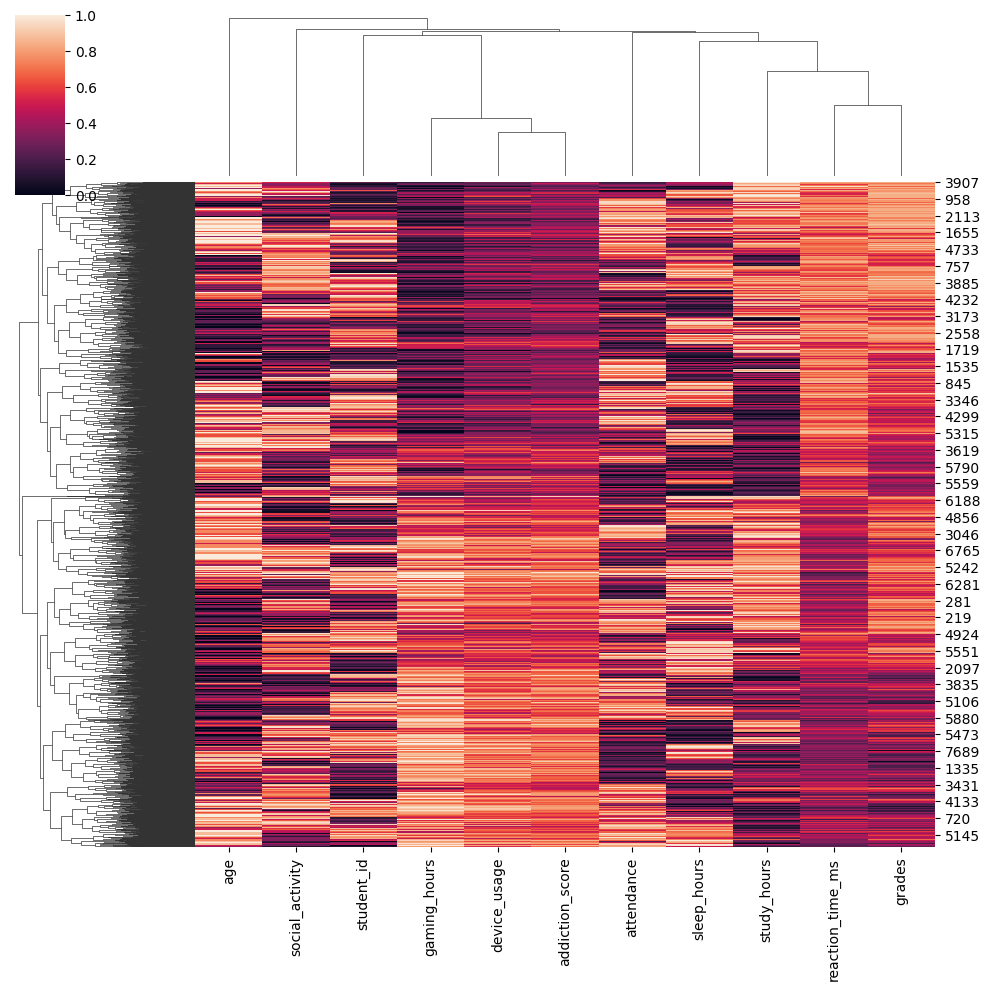

In [19]:
g = sns.clustermap(train_set[numeric_cols], standard_scale=1)
g.savefig('figures/gaming_clustermap.png', dpi=150, bbox_inches='tight')

Notes from this: 
Using the agglomerative clustering: 
Grades is most similar to reaction_time,
Grades are low when gaming_hours, device_usage, and addiction score tend to be low,
device_usage and addiction score are similar as is gaming hours.
More evidence that social_activity, age, and student_id are not very useful to a model.





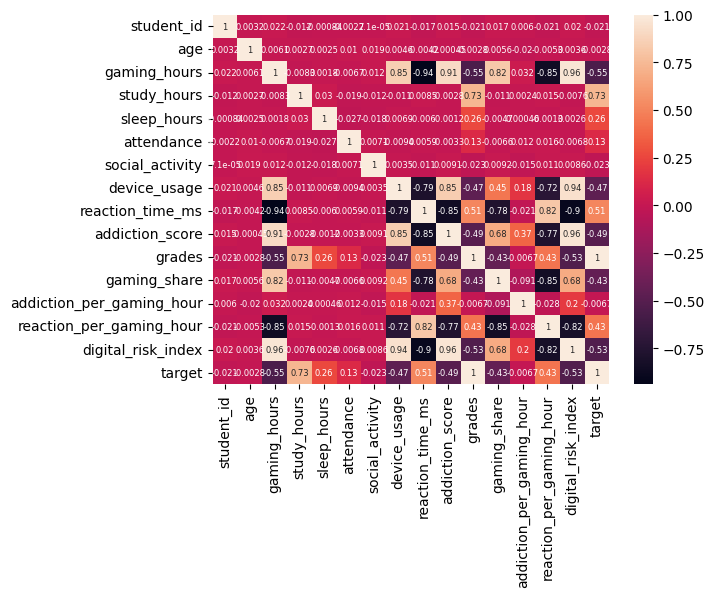

In [20]:
train_set["gaming_share"] = train_set["gaming_hours"] / train_set["device_usage"]
# Gaming as a fraction of total device time — distinguishes gamers from general users

# Addiction per hour gamed — high values suggest gaming is unhealthy at low volume
train_set["addiction_per_gaming_hour"] = train_set["addiction_score"] / (train_set["gaming_hours"] + 1)

# Reaction time relative to gaming exposure — practiced gamers should react faster
train_set["reaction_per_gaming_hour"] = train_set["reaction_time_ms"] / (train_set["gaming_hours"] + 1)

from sklearn.preprocessing import StandardScaler

cols = ["device_usage", "gaming_hours", "addiction_score"]
z = StandardScaler().fit_transform(train_set[cols])

# Risk index: high usage + high addiction + slow reactions all push it up
train_set["digital_risk_index"] = z[:, 0] + z[:, 1] + z[:, 2]

numeric_cols = train_set.select_dtypes(include="number").columns

df = train_set[numeric_cols].copy()
df["target"] = y_train

sns.heatmap(df.corr(), annot=True, annot_kws={"size": 6})
plt.savefig('figures/gaming_feature_engineering_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

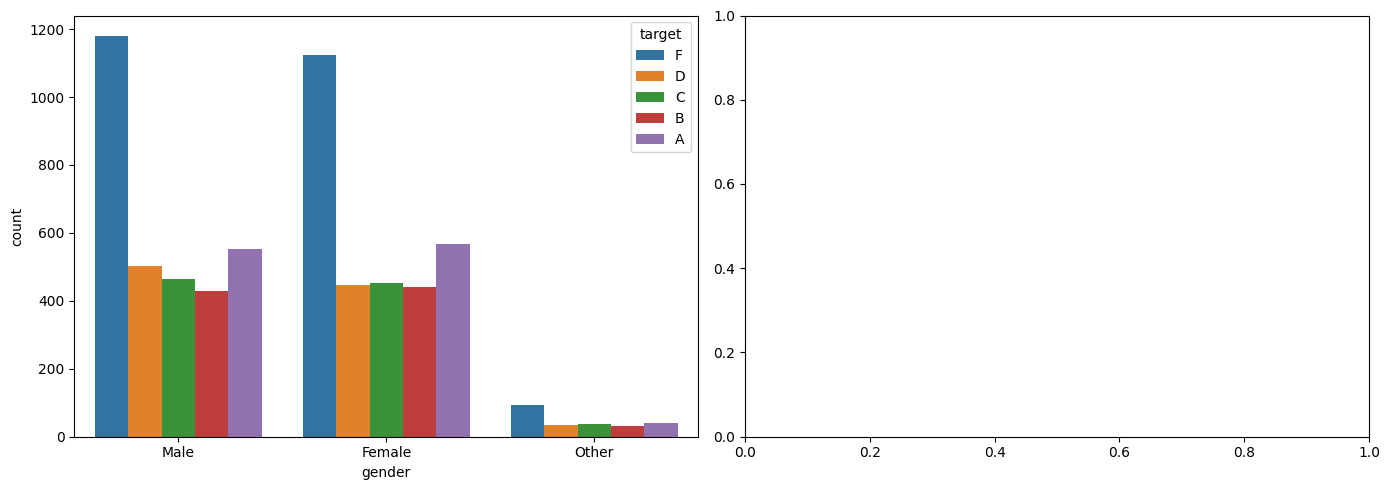

In [21]:
df = x_train.copy()
df["target"] = pd.cut(
    np.ravel(y_train),
    bins=[-float('inf'), 59, 69, 79, 89, float('inf')],
    labels=["F", "D", "C", "B", "A"],
    include_lowest=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="gender", hue="target", ax=axes[0])

plt.tight_layout()
plt.savefig('figures/gaming_gender_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
train_set

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,letter_grade,gaming_share,addiction_per_gaming_hour,reaction_per_gaming_hour,digital_risk_index
3174,3175,18,Male,0.37,3.99,7.26,82.18,RPG,3.15,5.94,311.57,4.27,Medium,76.600000,C,0.062290,3.116788,227.423358,-3.352979
830,831,23,Female,4.71,4.13,5.40,94.81,RPG,4.85,9.68,250.81,13.62,Medium,53.750000,F,0.486570,2.385289,43.924694,1.755412
4030,4031,21,Male,5.46,5.09,4.28,79.45,Casual,3.40,10.29,257.58,17.03,Low,54.790000,F,0.530612,2.636223,39.873065,2.980766
6386,6387,20,Male,1.44,5.64,6.30,83.00,FPS,2.26,4.58,277.97,1.95,Medium,86.844338,B,0.314410,0.799180,113.922131,-3.850111
4288,4289,17,Male,5.79,9.17,4.21,78.66,RPG,0.53,7.48,246.99,13.74,High,77.972778,C,0.774064,2.023564,36.375552,1.437781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4118,4119,23,Female,2.89,1.55,6.80,95.12,RPG,1.04,5.11,276.45,7.22,Medium,57.410000,F,0.565558,1.856041,71.066838,-1.982218
1393,1394,16,Female,2.95,2.13,5.56,96.71,RPG,3.48,6.19,281.64,7.13,Medium,62.645939,D,0.476575,1.805063,71.301266,-1.577006
4640,4641,21,Female,0.42,8.32,7.14,71.72,Casual,0.26,5.17,319.74,1.78,Medium,99.000000,A,0.081238,1.253521,225.169014,-4.108394
1764,1765,24,Male,0.73,9.83,8.41,66.21,Casual,1.69,3.72,302.98,3.31,Medium,100.000000,A,0.196237,1.913295,175.132948,-4.203845


In [23]:
train_set.drop(columns=['student_id', 'gaming_share',
       'addiction_per_gaming_hour', 'reaction_per_gaming_hour',
       'digital_risk_index'], inplace=True)

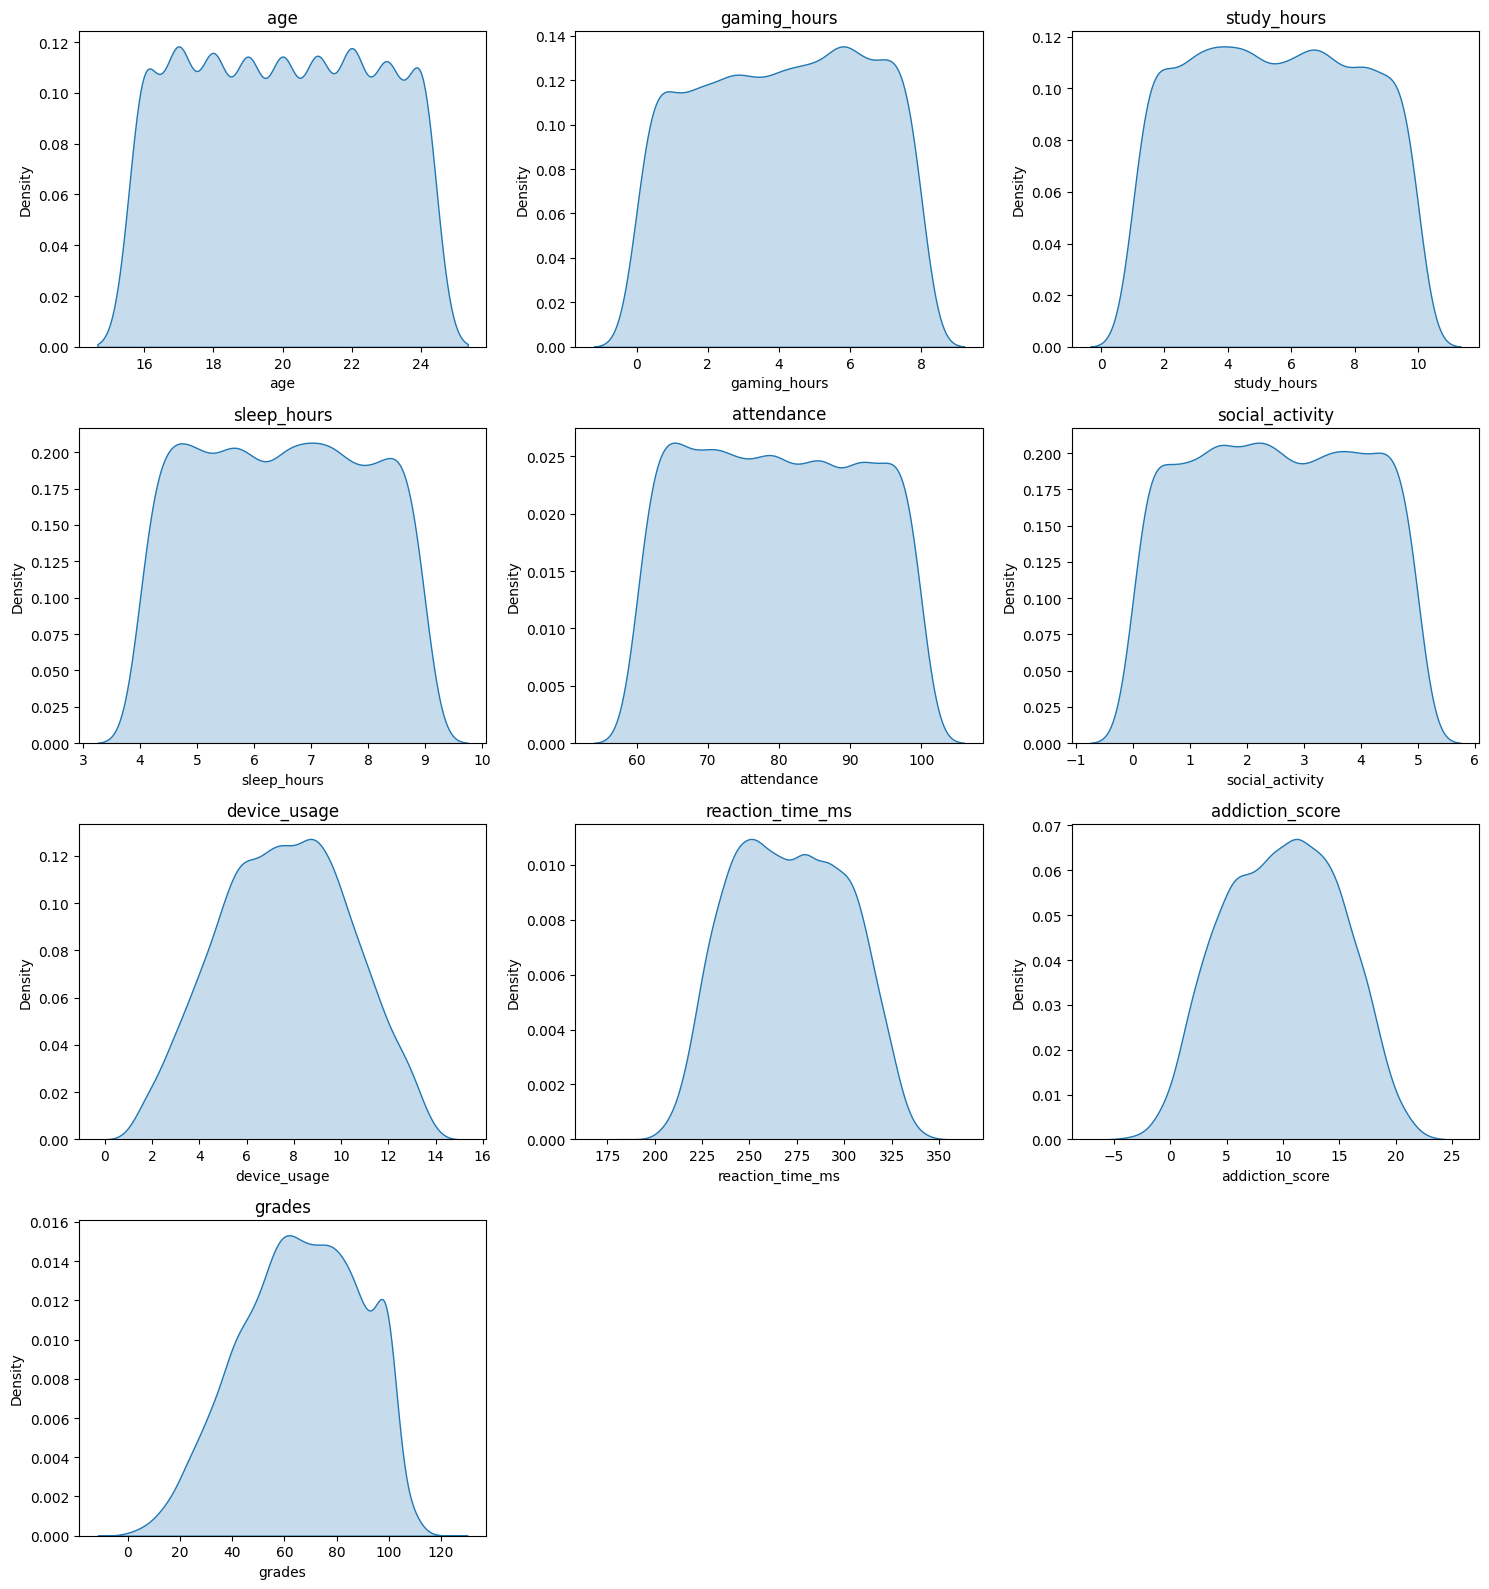

In [24]:
import math

numeric_cols = train_set.select_dtypes(include="number").columns

n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=train_set, x=col, ax=ax, fill=True)
    ax.set_title(col)

# Hide any unused subplots
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('figures/gaming_kde_plots.png', dpi=150, bbox_inches='tight')
plt.show()

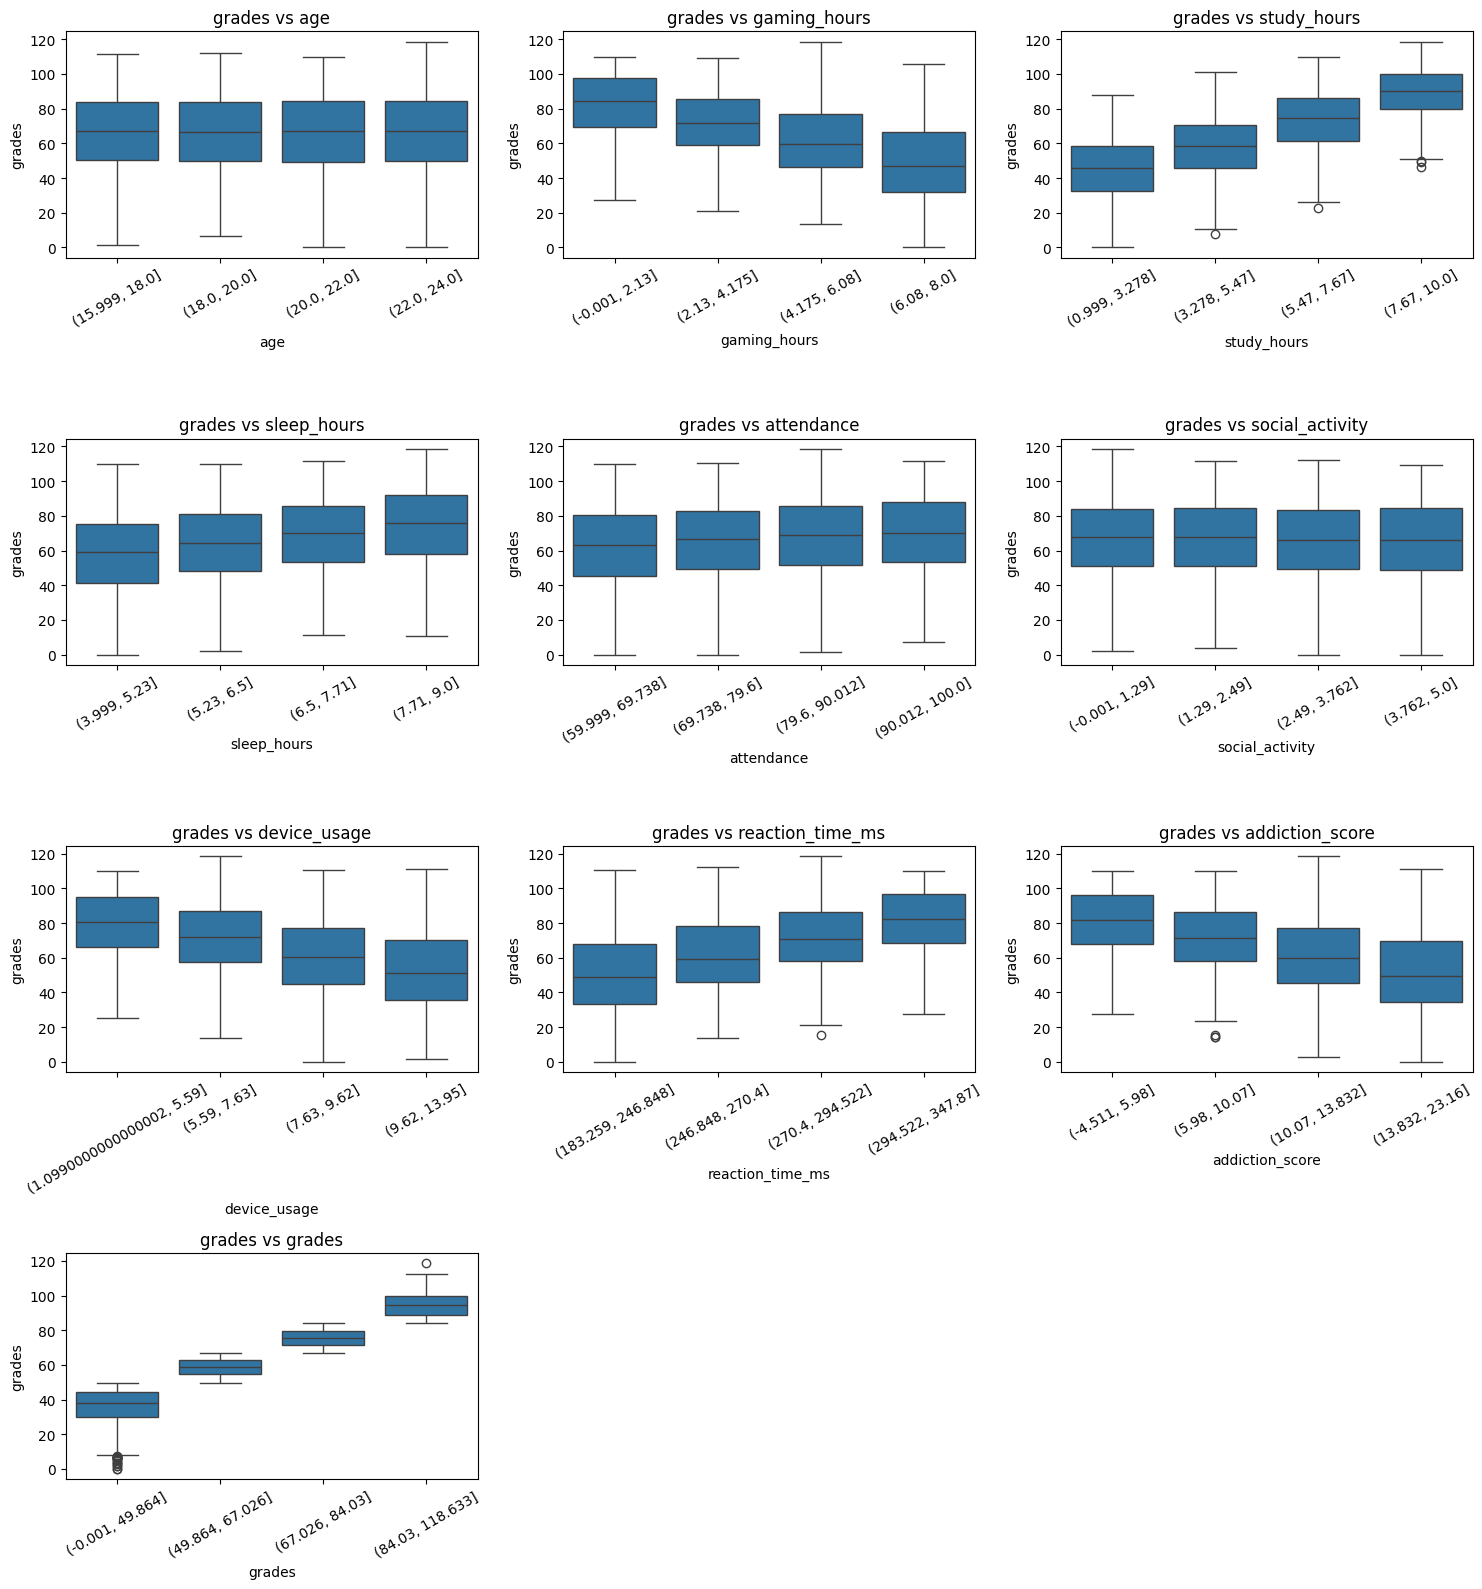

In [25]:
numeric_cols = train_set.select_dtypes(include="number").columns

n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    binned = pd.qcut(train_set[col], q=4, duplicates="drop")#bins each column into its four quartiles
    sns.boxplot(x=binned, y=train_set["grades"], ax=ax)
    #plots a box plot onto the specific section of the graph we request
    ax.set_title(f"grades vs {col}")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=30) 

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False) #sets the unused axes to invisible

plt.tight_layout()
plt.savefig('figures/gaming_grades_vs_features_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

These tell me largely what I already know

In [26]:
gamer_cols = ["gaming_hours", "device_usage", "addiction_score", "reaction_time_ms"]
# Note: flip reaction_time_ms since it goes the other direction
z = StandardScaler().fit_transform(train_set[gamer_cols])
z[:, 3] = -z[:, 3]  # flip reaction_time so all four point the same way
train_set["gamer_score"] = z.mean(axis=1)



In [27]:
train_set["gamer_score"].corr(train_set["grades"])

np.float64(-0.5349021906290984)

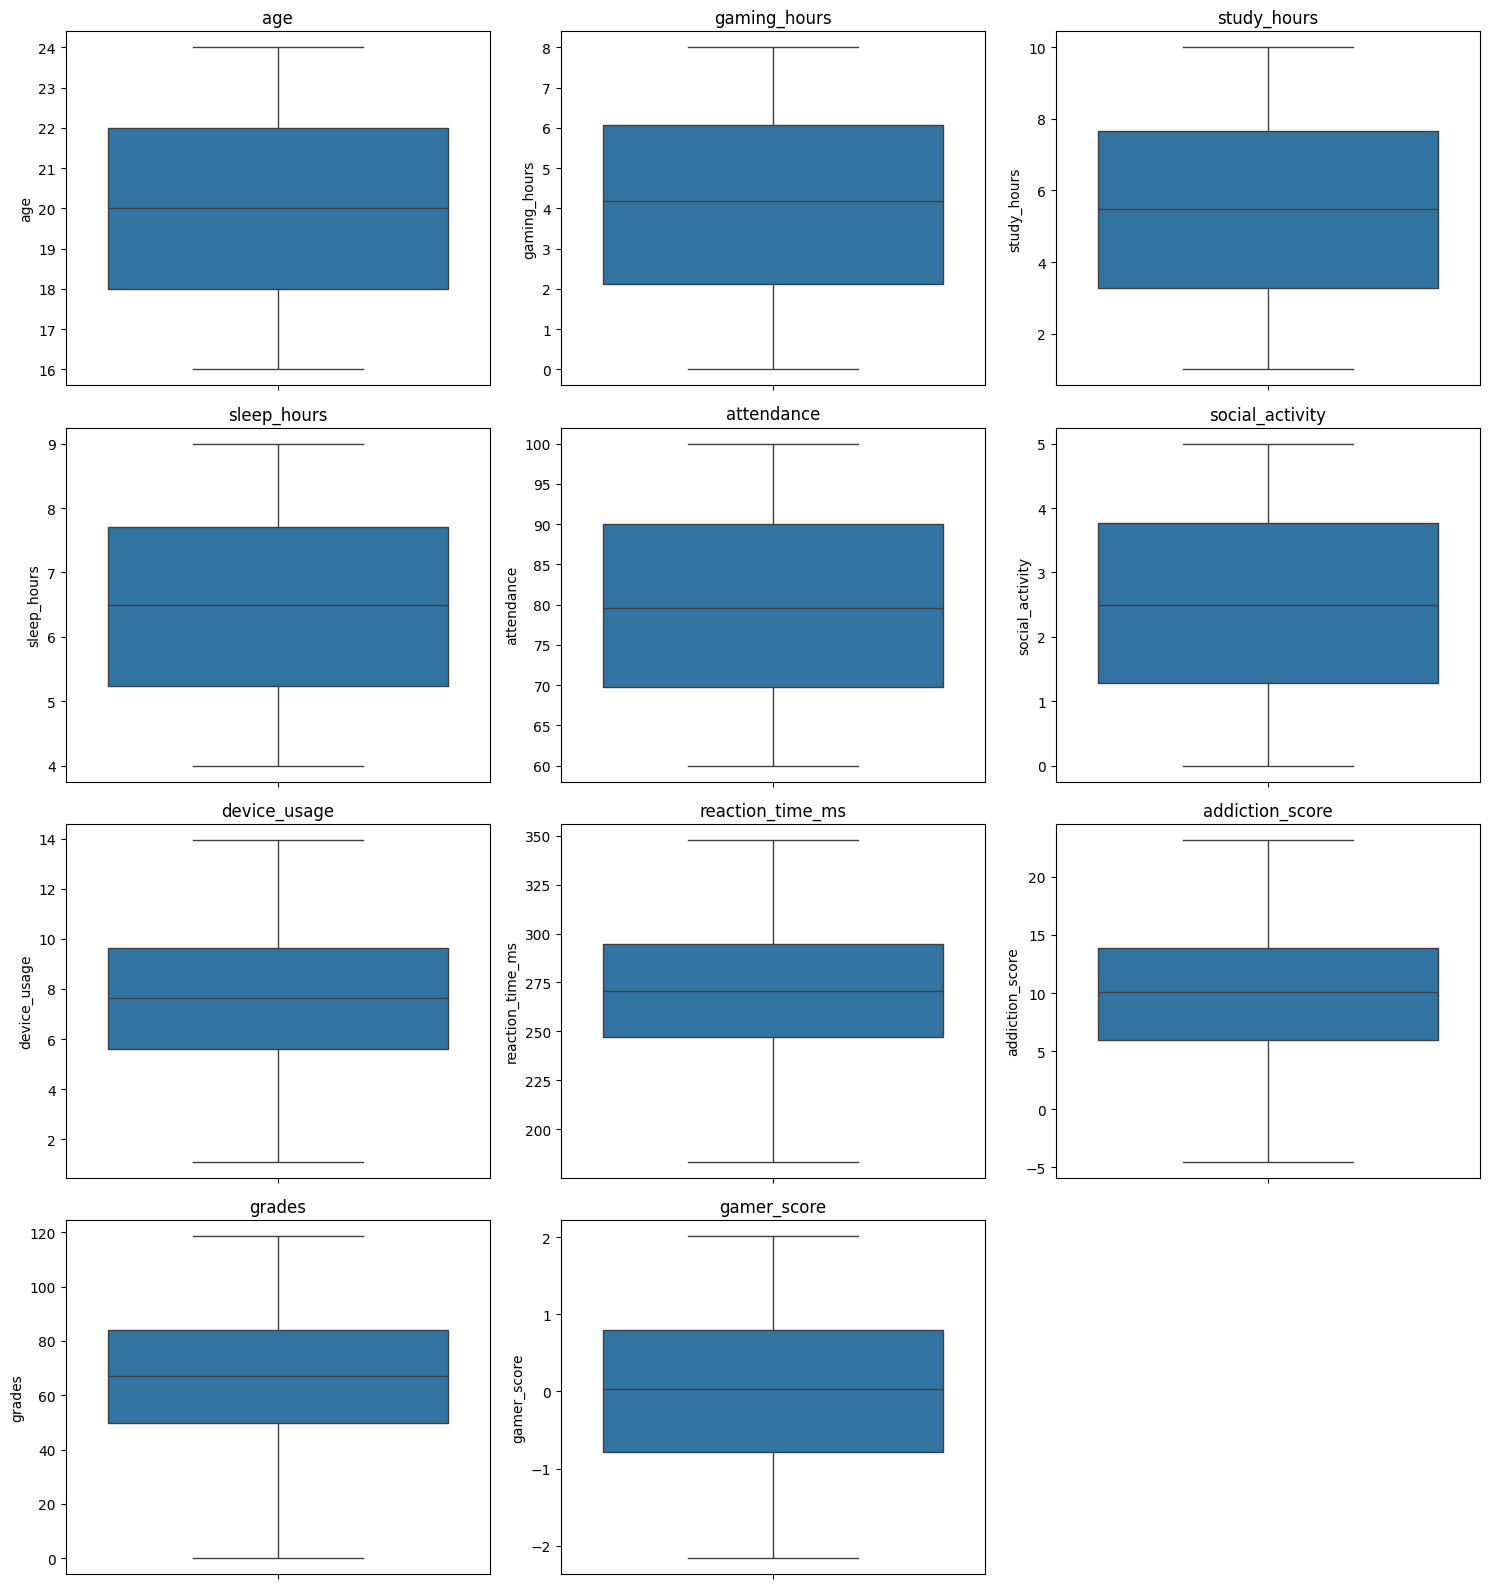

In [28]:
import math

numeric_cols = train_set.select_dtypes(include="number").columns

n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=train_set[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('figures/gaming_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = train_set[numeric_cols].apply(count_outliers_iqr)
outlier_pct = (outlier_counts / len(train_set) * 100).round(2)

print(pd.DataFrame({"count": outlier_counts, "pct": outlier_pct})
        .sort_values("count", ascending=False))

                  count  pct
age                   0  0.0
gaming_hours          0  0.0
study_hours           0  0.0
sleep_hours           0  0.0
attendance            0  0.0
social_activity       0  0.0
device_usage          0  0.0
reaction_time_ms      0  0.0
addiction_score       0  0.0
grades                0  0.0
gamer_score           0  0.0


In [30]:
x_train.columns

Index(['age', 'gender', 'gaming_hours', 'study_hours', 'sleep_hours',
       'attendance', 'gaming_genre', 'social_activity', 'device_usage',
       'reaction_time_ms', 'addiction_score', 'stress_level'],
      dtype='str')

In [31]:
c =  x_train.drop(columns=["age", "gender", "gaming_genre", "social_activity", "gaming_genre"])
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
c["stress_level"] = encoder.fit_transform(c[["stress_level"]]) - 1

In [32]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(c)
    scores[k] = silhouette_score(c, km.labels_)

In [33]:
scores

{2: 0.49469270974049695,
 3: 0.381199281513158,
 4: 0.31089391996985655,
 5: 0.31854766355063197,
 6: 0.32094604730326437,
 7: 0.32345701836417845,
 8: 0.3156473994318849,
 9: 0.3070239746875286,
 10: 0.3031030776386921}

No clustering seems particularly useful.